## Polynomial Regression Implementation

In [93]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

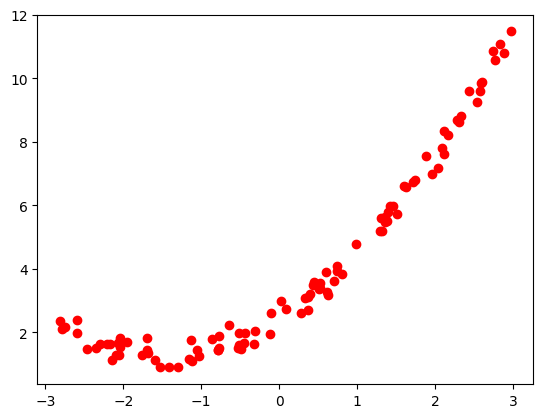

In [94]:
## Quadratic data
X= 6 * np.random.rand(100,1) - 3
y= 0.5 * X**2 + 1.5 * X + 2 + np.random.rand(100,1)
plt.scatter(X, y, color='red')

In [95]:
## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
##  Normal linear regression model on the data
linear_reg= LinearRegression()
linear_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
y_pred1= linear_reg.predict(X_test)
score = r2_score(y_test, y_pred1)
print(f'R2 score with linear regression is {score}')


R2 score with linear regression is 0.7861222439190577


Text(0.5, 1.0, 'Linear Regression on Quadratic Data')

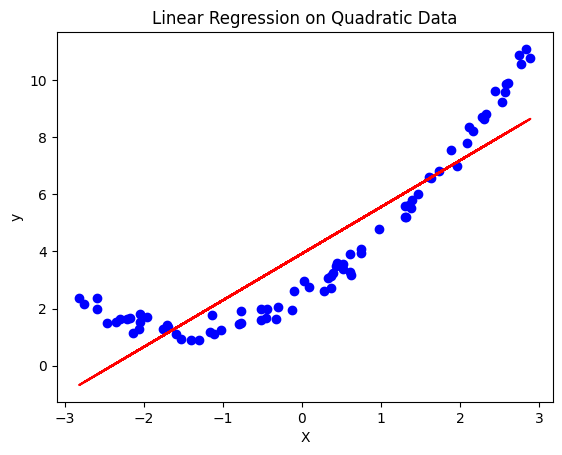

In [98]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, linear_reg.predict(X_train), color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression on Quadratic Data')

In [99]:
## Apply polynomial features to the data
poly=PolynomialFeatures(degree=2, include_bias=True)
X_poly_train= poly.fit_transform(X_train)
X_poly_test= poly.transform(X_test)

In [100]:
## Now apply linear regression to the polynomial features
regression= LinearRegression()
regression.fit(X_poly_train, y_train)
y_pred2= regression.predict(X_poly_test)
score_poly = r2_score(y_test, y_pred2)
print(f'Coefficients of the polynomial regression model: {regression.coef_}')
print(f'R2 score with polynomial regression is {score_poly}')


Coefficients of the polynomial regression model: [[0.         1.54778338 0.51202691]]
R2 score with polynomial regression is 0.9888517722766847


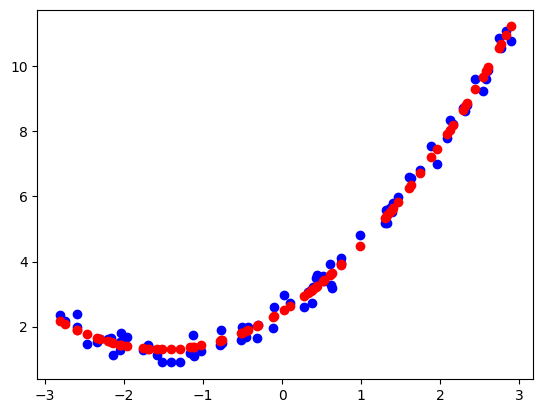

In [101]:
## Plot the polynomial regression results
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_train, regression.predict(X_poly_train), color='red')

Coefficients of the cubic regression model: [[ 0.          1.64575952  0.51739211 -0.01925261]]
R2 score with cubic regression is 0.9866811615569321


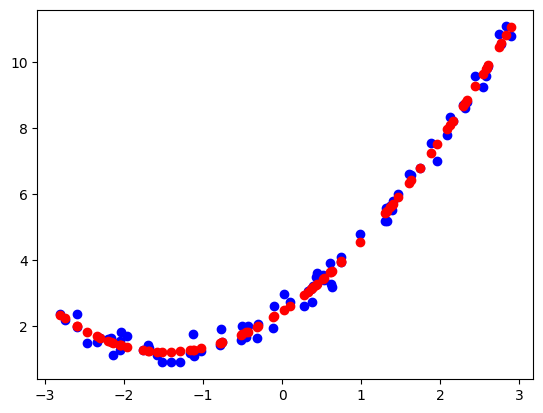

In [102]:
## Increase the degree of the polynomial features to 3
poly3=PolynomialFeatures(degree=3, include_bias=True)
X_poly3_train= poly3.fit_transform(X_train)
X_poly3_test= poly3.transform(X_test)
poly3_reg= LinearRegression()
poly3_reg.fit(X_poly3_train, y_train)
y_pred3= poly3_reg.predict(X_poly3_test)
score_poly3 = r2_score(y_test, y_pred3)
print(f'Coefficients of the cubic regression model: {poly3_reg.coef_}')
print(f'R2 score with cubic regression is {score_poly3}')
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_train, poly3_reg.predict(X_poly3_train), color='red')

In [103]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

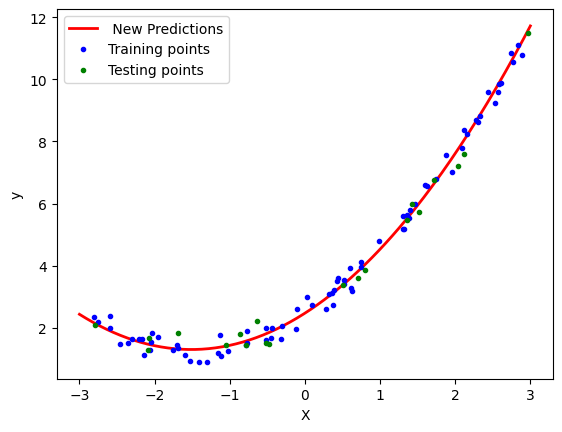

In [104]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline 

In [105]:
def polynomial_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train)
    y_pred_new=poly_regression.predict(X_new)
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

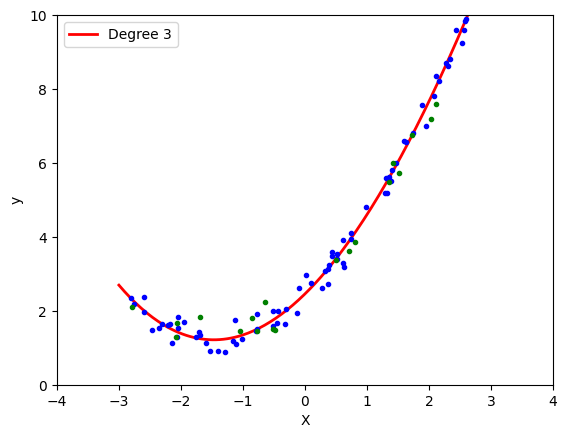

In [106]:
polynomial_regression(3)